In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [26]:
import pandas as pd

df = pd.read_csv('/content/drive/My Drive/Advertising.csv')

df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [27]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Basic Information

In [28]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TV Ad Budget ($)         200 non-null    float64
 1   Radio Ad Budget ($)      200 non-null    float64
 2   Newspaper Ad Budget ($)  200 non-null    float64
 3   Sales ($)                200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


,0
TV Ad Budget ($),0
Radio Ad Budget ($),0
Newspaper Ad Budget ($),0
Sales ($),0


# Pair Plot

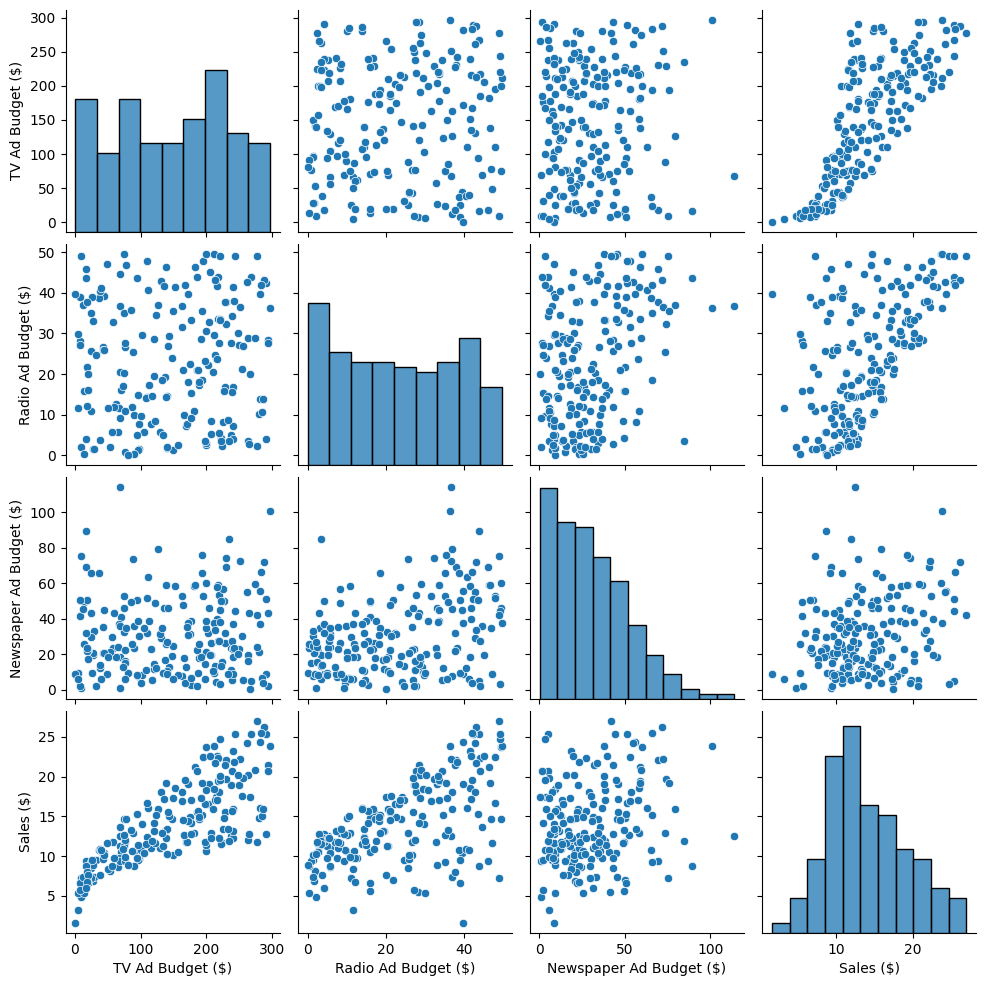

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df)

plt.show()

# Individual Scatter plot

## TV Vs Sales

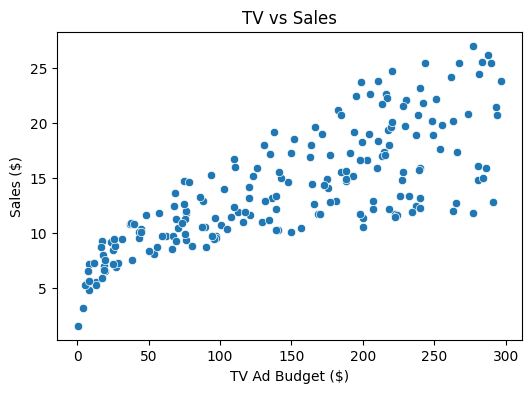

In [30]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="TV Ad Budget ($)",y="Sales ($)",data=df)
plt.title("TV vs Sales")
plt.show()

## Radio Vs Sales

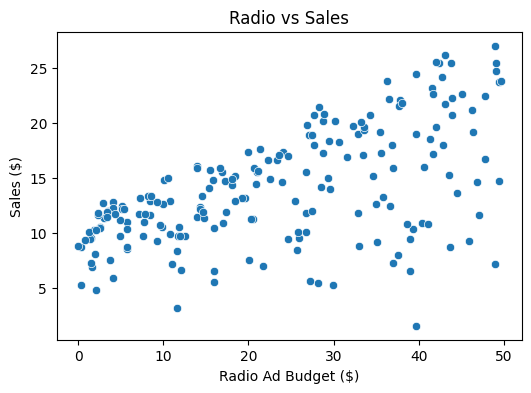

In [31]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Radio Ad Budget ($)",y="Sales ($)",data=df)
plt.title("Radio vs Sales")
plt.show()

## Newspaper Vs Sales

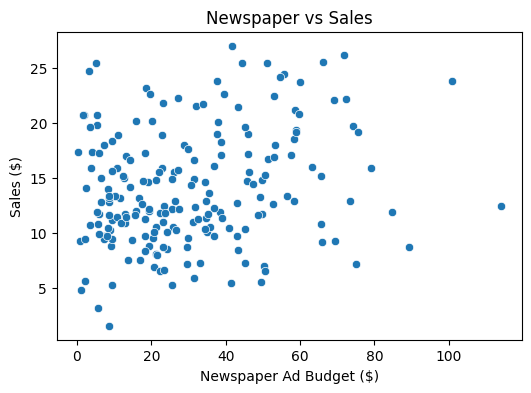

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.scatterplot(x="Newspaper Ad Budget ($)",y="Sales ($)",data=df)
plt.title("Newspaper vs Sales")
plt.show()

# Correlation Heat Map

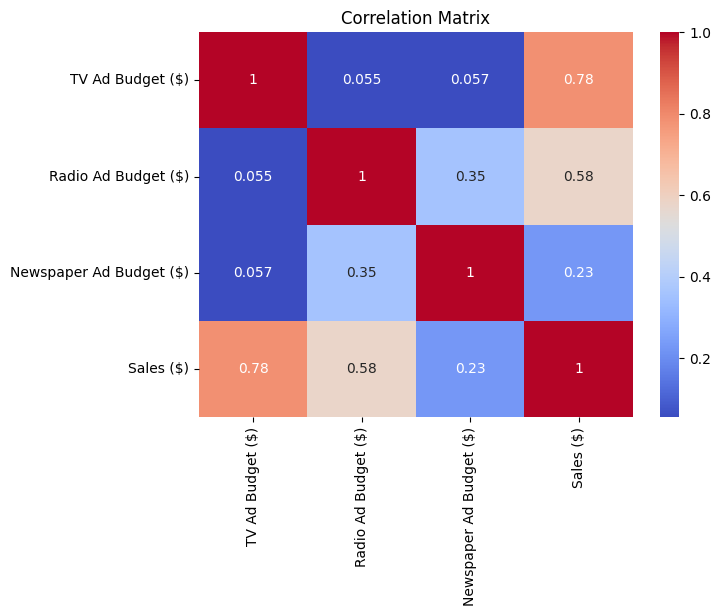

In [33]:
plt.figure(figsize=(7,5))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

# Train Test Split

In [43]:
X = df.drop("Sales ($)",axis=1)
y = df["Sales ($)"]
X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.2,random_state=42)

# linear regression

In [44]:
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

# Evaluation

In [45]:
mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))

r2 = r2_score(y_test,y_pred)

print("Linear Regression Results")

print("MAE :",mae)

print("RMSE :",rmse)

print("R2 Score :",r2)

Linear Regression Results
MAE : 1.4607567168117603
RMSE : 1.78159966153345
R2 Score : 0.899438024100912


# Residual Plot

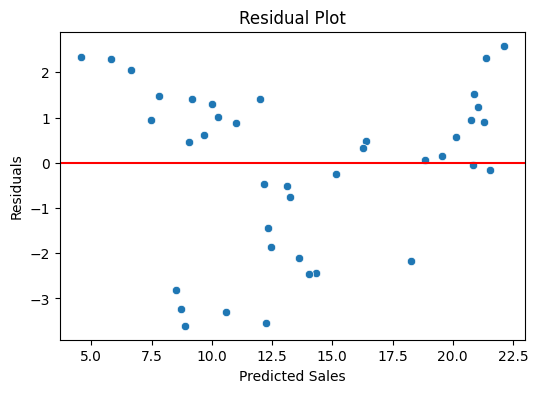

In [46]:
residuals = y_test-y_pred

plt.figure(figsize=(6,4))

sns.scatterplot(x=y_pred,y=residuals)

plt.axhline(0,color="red")

plt.xlabel("Predicted Sales")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

# Random Forest Regressor

In [47]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

# Random Forest Evaluation

In [49]:
rf_mae = mean_absolute_error(y_test,rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test,rf_pred))

rf_r2 = r2_score(y_test,rf_pred)

print("Random Forest Results")

print("MAE :",rf_mae)

print("RMSE :",rf_rmse)

print("R2 Score :",rf_r2)

Random Forest Results
MAE : 0.6200999999999988
RMSE : 0.7685910811348248
R2 Score : 0.9812843792541843


# Feature Importance

In [50]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                   Feature  Importance
0         TV Ad Budget ($)    0.624810
1      Radio Ad Budget ($)    0.362201
2  Newspaper Ad Budget ($)    0.012989


# Feature Importance Graph

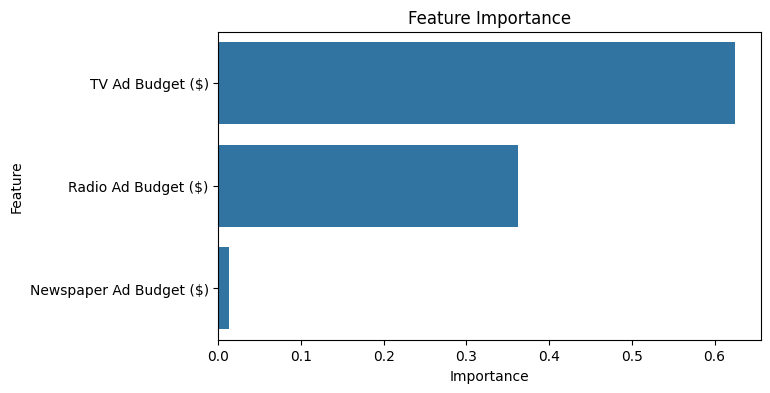

In [51]:
plt.figure(figsize=(7,4))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

# Linear Regression Coefficients

In [52]:
coef = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":lr.coef_
})

coef

,Feature,Coefficient
0,TV Ad Budget ($),0.044730
1,Radio Ad Budget ($),0.189195
2,Newspaper Ad Budget ($),0.002761


# Model Comparison

In [53]:
comparison = pd.DataFrame({

    "Model":["Linear Regression",
             "Random Forest"],

    "MAE":[mae,
           rf_mae],

    "RMSE":[rmse,
            rf_rmse],

    "R2 Score":[r2,
                rf_r2]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620100,0.768591,0.981284
